<a id="introduction"></a>

# PS4: Restricted Boltzmann Machines and MNIST Digit Recall

Handwritten digit images from the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database) contain rich spatial structure — stroke patterns, curves, and intersections that co-occur across examples of the same digit. In this problem set, we explore how two associative memory models — the classical Hopfield network and the restricted Boltzmann machine (RBM) — store and recall digit patterns from corrupted inputs.

The [Hopfield network](https://en.wikipedia.org/wiki/Hopfield_network) stores patterns in a Hebbian weight matrix and retrieves them by minimizing an energy function through iterative state updates. The [restricted Boltzmann machine](https://en.wikipedia.org/wiki/Restricted_Boltzmann_machine) takes a different approach: it learns a probability distribution over binary pixel patterns and reconstructs inputs via block Gibbs sampling. We compare both models on the same recall task — recovering a corrupted MNIST digit — and then examine how model capacity and training data affect reconstruction quality.

> __Learning Objectives__
> 
> By the end of this problem set, you should be able to:
>
> * __Hopfield network recall:__ Build a memory matrix from MNIST digit patterns and apply Hopfield network dynamics to reconstruct stored patterns from corrupted inputs. Analyze how the number of stored patterns affects recall quality.
> * __RBM training with contrastive divergence:__ Train a small restricted Boltzmann machine on MNIST digit images using the CD-1 algorithm and evaluate reconstruction accuracy on corrupted test patterns. Compare performance against the classical Hopfield network.
> * __Pretrained RBM recall:__ Load a pretrained RBM and use block Gibbs sampling to reconstruct corrupted MNIST digits. Compare recall quality against the small trained RBM across different corruption fractions.

Let's get started!
___

<a id="setup"></a>

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and sets the random seed. For more information, see the [VLDataScienceMachineLearningPackage.jl documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) for RBM operations and MNIST data loading. Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material. Because multiple packages export a `sample` function, we use the explicit module prefix `VLDataScienceMachineLearningPackage.sample(...)` for RBM Gibbs sampling.

### Constants
We define constants that control the experiment setup, model architecture, and training configuration. The comment next to each constant describes its purpose, units, and permissible values.

In [ ]:
# Image dimensions (MNIST: 28 x 28 pixels)
n_rows    = 28;
n_cols    = 28;
n_pixels  = n_rows * n_cols;        # 784 visible units

# Data loading
number_of_examples   = 50;          # patterns to store in memory matrix (Task 1)
digit_for_experiment = 3;           # MNIST digit to use (0-9)
digit_to_compare     = 7;           # second digit for cross-model comparison
n_train              = 50;          # training examples for small RBM (Task 2)

# Small RBM architecture (Task 2)
n_visible       = n_pixels;         # 784 visible units
n_hidden_small  = 128;              # hidden units in small RBM
n_epochs        = 200;               # training epochs
batchsize_train = 20;               # mini-batch size
n_updates_per_epoch = ceil(Int, n_train / batchsize_train);
eta_train       = 0.01;             # learning rate
beta_train      = 1.0;             # inverse temperature during training

# Recall parameters
n_gibbs_recall  = 50;               # Gibbs steps for RBM recall
beta_recall     = 1.0;             # inverse temperature for recall
corruption_frac = 0.30;            # default corruption fraction
n_hopfield_steps = 20;             # Hopfield dynamics steps

# Visualization
n_show = 6;                        # number of stored patterns to visualize

### Implementation
The notebook uses local helper functions for MNIST image handling:

> * `decode(s; number_of_rows, number_of_columns)`: Converts a flattened state vector back to a 2D image matrix for visualization.
> * `corrupt(v, frac; seed)`: Flips a random fraction of bits in a binary pattern to simulate noisy input.
> * `tanimoto(a, b)`: Computes the Tanimoto (Jaccard) similarity between two binary vectors, measuring recall quality.

> __`decode(s; number_of_rows, number_of_columns)`__
>
> Converts a flattened state vector $\mathbf{s}$ (with values in $\{-1, +1\}$ or $\{0, 1\}$) back to a 2D image matrix. The function reshapes the vector, transposes to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

Let's implement the `decode(...)` function:

In [93]:
function decode(s::Vector{<:Number}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{<:Number,2}
    X  = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂  = replace(X, -1 => 0);
    return X̂
end;

> __`corrupt(v, frac; seed)`__
>
> Corrupts a binary $\{-1, +1\}$ pattern $\mathbf{v}$ by flipping a random fraction `frac` of its bits. Each flipped bit changes sign: $v_i \leftarrow -v_i$. This simulates noisy or partially observed inputs for the recall task.

Let's implement the `corrupt(...)` function:

In [94]:
function corrupt(v::Vector{Int64}, frac::Float64; seed::Int=42)::Vector{Int64}
    n       = length(v);
    n_flip  = round(Int, frac * n);
    rng     = MersenneTwister(seed);
    flip_idx = StatsBase.sample(rng, 1:n, n_flip, replace=false);
    v_corr  = copy(v);
    v_corr[flip_idx] .*= -1;
    return v_corr
end;

> __`tanimoto(a, b)`__
>
> Computes the Tanimoto (Jaccard) similarity between two $\{0, 1\}$ binary vectors. The Tanimoto coefficient is $T(\mathbf{a}, \mathbf{b}) = \frac{\langle \mathbf{a}, \mathbf{b} \rangle}{\|\mathbf{a}\|_1 + \|\mathbf{b}\|_1 - \langle \mathbf{a}, \mathbf{b} \rangle}$, which equals 0 when the patterns share no "on" pixels and 1 when they are identical. Unlike bit accuracy, Tanimoto is not inflated by background pixels.

Let's implement the `tanimoto(...)` function:

In [95]:
function tanimoto(a::Vector{<:Number}, b::Vector{<:Number})::Float64
    ab = dot(a, b);
    denom = sum(a) + sum(b) - ab;
    return denom == 0 ? 0.0 : ab / denom
end;

___
<a id="task1"></a>

## Task 1: Memory Matrix and Hopfield Recall
A [Hopfield network](https://en.wikipedia.org/wiki/Hopfield_network) stores binary patterns as a symmetric weight matrix and retrieves them by iteratively updating each unit's state to minimize a global energy function. Given a set of $N$ stored patterns $\left\{\boldsymbol{\xi}^{(1)},\ldots,\boldsymbol{\xi}^{(N)}\right\}$ with $\boldsymbol{\xi}^{(\mu)}\in\{-1,+1\}^{n}$, the Hebbian learning rule constructs the weight matrix as an outer-product sum:

$$
\mathbf{W} = \frac{1}{N}\sum_{\mu=1}^{N}\boldsymbol{\xi}^{(\mu)}\left(\boldsymbol{\xi}^{(\mu)}\right)^{\top},\qquad w_{ii}=0.
$$

Recall dynamics update the state as $\mathbf{v}^{(t+1)} = \text{sign}\!\left(\mathbf{W}\,\mathbf{v}^{(t)}\right)$, which is guaranteed to converge to a local minimum of the energy function $E(\mathbf{v}) = -\frac{1}{2}\mathbf{v}^{\top}\mathbf{W}\,\mathbf{v}$. In this task, we build a memory matrix from MNIST digit examples and test whether Hopfield dynamics can recover a stored pattern from a corrupted input.

> __Memory matrix construction__
>
> We load `number_of_examples` images of `digit_for_experiment` from the MNIST dataset, threshold each pixel at $0.5$ to obtain a binary $\{0, 1\}$ image, convert to $\{-1, +1\}$ encoding, and store each flattened pattern as a column of $\mathbf{X}_{\pm 1} \in \mathbb{Z}^{n_{pixels} \times N}$.

Let's load the MNIST data and build the memory matrix:

In [96]:
digits_dict, X, X_pm1 = let

    # load MNIST images
    digits_dict = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples + 10);

    # initialize memory matrices
    X     = zeros(Float64, n_pixels, number_of_examples);  # {0,1} encoding
    X_pm1 = zeros(Int64,   n_pixels, number_of_examples);  # {-1,+1} encoding

    for i in 1:number_of_examples
        img           = digits_dict[digit_for_experiment][:, :, i];
        v             = Float64.(img)[:];
        b             = (v .> 0.5);
        X[:, i]       = Float64.(b);
        X_pm1[:, i]   = Int64.(2 .* b .- 1);
    end

    println("Memory matrix: $(size(X_pm1, 1)) pixels x $(size(X_pm1, 2)) stored patterns")
    (digits_dict, X, X_pm1)
end;

Memory matrix: 784 pixels x 50 stored patterns


> __Visualize stored patterns__
>
> Before running recall, we display a subset of the stored patterns to confirm the memory matrix was constructed correctly. Each column of $\mathbf{X}\in\{0,1\}^{n_{\text{pixels}}\times N}$ is reshaped to a $28\times 28$ image using the `decode(...)` function.

Let's visualize the first `n_show::Int` stored patterns.

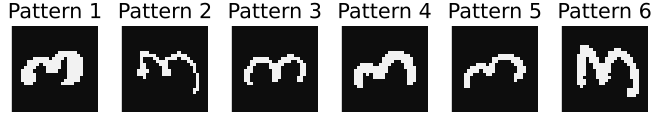

In [97]:
let
    p_list = [];
    for k in 1:n_show
        img = decode(X[:, k]);
        p   = heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title="Pattern $k", axis=false, ticks=false);
        push!(p_list, p);
    end
    plot(p_list..., layout=(1, n_show), size=(660, 130))
end

> __Hopfield weight matrix (Hebbian rule)__
>
> The Hopfield weight matrix is $\mathbf{W} = \frac{1}{N} \mathbf{X}_{\pm 1} \mathbf{X}_{\pm 1}^{\top} \in \mathbb{R}^{n_{pixels} \times n_{pixels}}$, where $N$ is the number of stored patterns. The diagonal is zeroed to prevent trivial self-reinforcement. Recall dynamics update the state as $\mathbf{v}^{(t+1)} = \text{sign}(\mathbf{W} \mathbf{v}^{(t)})$ until convergence or for `n_hopfield_steps` iterations.

Let's compute the Hopfield weight matrix:

In [98]:
W_hopfield = let
    N = size(X_pm1, 2);
    W = (X_pm1 * X_pm1') ./ N;
    W[diagind(W)] .= 0.0;
    W
end;

> __Recall from a corrupted input__
>
> We select a held-out test image (not used to build the memory matrix), corrupt it by flipping `corruption_frac` $= 30\%$ of its bits using the `corrupt(...)` function, and run Hopfield dynamics for `n_hopfield_steps::Int` $= 20$ iterations. The Tanimoto similarity between the recalled pattern and the original measures recall quality on a scale from $0$ (no overlap) to $1$ (identical).

Let's run the Hopfield recall experiment.

In [99]:
v_original, v_corrupted, v_recalled = let

    # held-out image: index number_of_examples + 1
    img    = digits_dict[digit_for_experiment][:, :, number_of_examples + 1];
    v      = Float64.(img)[:];
    b      = (v .> 0.5);
    v_orig = Int64.(2 .* b .- 1);

    # corrupt
    v_corr = corrupt(v_orig, corruption_frac; seed=1);

    # Hopfield dynamics: v <- sign(W * v)
    v_state = copy(v_corr);
    for _ in 1:n_hopfield_steps
        v_state = sign.(W_hopfield * v_state);
        v_state[v_state .== 0] .= 1;  # break ties
    end

    println("Corruption fraction           : $(corruption_frac)")
    println("Tanimoto similarity (Hopfield recall): $(round(tanimoto(Float64.(((v_state) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2)), digits=3))")
    (v_orig, v_corr, v_state)
end;

Corruption fraction           : 0.3
Tanimoto similarity (Hopfield recall): 0.136


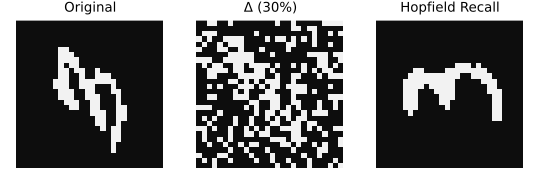

In [100]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_recalled)];
    titles = ["Original",
              "Δ ($(round(Int, corruption_frac*100))%)",
              "Hopfield Recall"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, titlefontsize=9, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

> __What do we observe?__
>
> The Hopfield network struggles to recall the original digit from $30\%$ corruption. With $N = 50$ stored patterns (below the theoretical capacity of $\sim 108$), the network should store patterns without interference, but the recall dynamics may converge to a spurious attractor rather than the correct stored pattern. The low Tanimoto similarity confirms poor recall quality.

___
<a id="task2"></a>

## Task 2: Train a Small RBM
The Hopfield network encodes patterns through a deterministic outer-product rule and retrieves them by energy minimization. This approach is limited by a fixed storage capacity and produces hard binary outputs with no measure of uncertainty. A [restricted Boltzmann machine (RBM)](https://en.wikipedia.org/wiki/Restricted_Boltzmann_machine) takes a different approach: it learns a probability distribution over binary patterns from training data and reconstructs inputs via block Gibbs sampling. The bipartite structure of the RBM (no within-layer connections) enables efficient parallel updates of all hidden or all visible units in a single step.

We train a small RBM with `n_visible::Int` $= 784$ visible units and `n_hidden_small::Int` $= 128$ hidden units on `n_train::Int` $= 50$ images of digit `digit_for_experiment::Int` using contrastive divergence (CD-1). After training, we reconstruct the same corrupted held-out digit from Task 1 and compare recall quality.

> __Training data preparation__
>
> We load `n_train` images of `digit_for_experiment` from the MNIST dataset and convert them to a $\{-1, +1\}$ integer matrix of shape $(n_{pixels} \times n_{train})$. A uniform `Categorical` distribution over the training indices serves as the data sampling distribution for the `learn(...)` function.

Let's prepare the training data:

In [101]:
X_train_pm1, p_train = let

    X_train_pm1 = zeros(Int64, n_pixels, n_train);

    for i in 1:n_train
        img              = digits_dict[digit_for_experiment][:, :, i];
        v                = Float64.(img)[:];
        b                = (v .> 0.5);
        X_train_pm1[:, i] = Int64.(2 .* b .- 1);
    end

    p_train = Categorical(n_train);

    println("Training data: $(size(X_train_pm1, 1)) pixels x $(size(X_train_pm1, 2)) examples")
    (X_train_pm1, p_train)
end;

Training data: 784 pixels x 50 examples


> __Contrastive divergence training (CD-1)__
>
> We initialize the RBM with small random weights and zero biases, then train for `n_epochs` epochs. Each epoch runs `n_updates_per_epoch` mini-batch updates using the `learn(...)` function with `T=2` Gibbs steps (CD-1, since the package counts the initial state as step 1). After each epoch, we compute the mean reconstruction error (fraction of bits incorrectly reconstructed) on a 5-image probe set.

Let's train the small RBM:

In [102]:
rbm_small, reconstruction_errors = let

    # build W (diag = 0)
    W = 0.01 * randn(n_visible, n_hidden_small);
    W[diagind(W)] .= 0.0;

    # initialize model
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = W,
        b = zeros(n_hidden_small),
        a = zeros(n_visible)
    ));

    n_probe    = min(5, n_train);
    probe_idx  = 1:n_probe;
    recon_errs = Float64[];

    for epoch in 1:n_epochs
        rbm = learn(rbm, X_train_pm1, p_train;
            maxnumberofiterations = n_updates_per_epoch,
            T         = 2,
            β         = beta_train,
            batchsize = batchsize_train,
            η         = eta_train,
            tol       = 1e-10,
            verbose   = false);

        # reconstruction error on probe set
        total_err = 0.0;
        for i in probe_idx
            v0 = X_train_pm1[:, i];
            (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm, v0; T=2, β=beta_train);
            total_err += mean(v0 .!= V_rec[:, end]);
        end
        push!(recon_errs, total_err / n_probe);

        epoch % 5 == 0 && println("Epoch $(lpad(epoch,3)) | recon error = $(round(recon_errs[end], digits=4))");
    end

    (rbm, recon_errs)
end;

Epoch   5 | recon error = 0.1176
Epoch  10 | recon error = 0.139
Epoch  15 | recon error = 0.1151
Epoch  20 | recon error = 0.1296
Epoch  25 | recon error = 0.1403
Epoch  30 | recon error = 0.1173
Epoch  35 | recon error = 0.1191
Epoch  40 | recon error = 0.1202
Epoch  45 | recon error = 0.1189
Epoch  50 | recon error = 0.1222
Epoch  55 | recon error = 0.1143
Epoch  60 | recon error = 0.1194
Epoch  65 | recon error = 0.1196
Epoch  70 | recon error = 0.1153
Epoch  75 | recon error = 0.1411
Epoch  80 | recon error = 0.1395
Epoch  85 | recon error = 0.1125
Epoch  90 | recon error = 0.1161
Epoch  95 | recon error = 0.1199
Epoch 100 | recon error = 0.114
Epoch 105 | recon error = 0.123
Epoch 110 | recon error = 0.1278
Epoch 115 | recon error = 0.1158
Epoch 120 | recon error = 0.1214
Epoch 125 | recon error = 0.1148
Epoch 130 | recon error = 0.1304
Epoch 135 | recon error = 0.1189
Epoch 140 | recon error = 0.1163
Epoch 145 | recon error = 0.1365
Epoch 150 | recon error = 0.1196
Epoch 155 | r

> __Training convergence__
>
> The reconstruction error (fraction of incorrectly reconstructed bits on a probe set) should decrease or plateau over training epochs as the RBM learns the co-occurrence structure of the digit patterns.

Let's plot the reconstruction error over epochs.

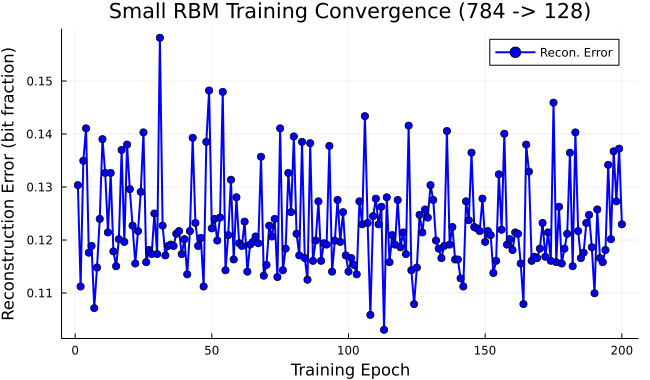

In [103]:
let
    plot(1:n_epochs, reconstruction_errors,
         xlabel = "Training Epoch",
         ylabel = "Reconstruction Error (bit fraction)",
         title  = "Small RBM Training Convergence ($(n_visible) -> $(n_hidden_small))",
         label  = "Recon. Error",
         lw = 2, color = :blue, marker = :circle, size = (650, 380))
end

> __Small RBM recall__
>
> We apply the same corruption used in Task 1 to the held-out digit and reconstruct it using `n_gibbs_recall::Int` $= 50$ steps of block Gibbs sampling with the trained small RBM. This tests whether the RBM learned a distribution that can denoise corrupted inputs.

Let's run the small RBM recall experiment.

In [104]:
v_rbm_recalled = let

    v0_pm1 = corrupt(v_original, corruption_frac; seed=1);  # same corruption as Task 1
    (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v0_pm1;
                     T=n_gibbs_recall, β=beta_recall);
    v_rec = V_rec[:, end];

    println("Tanimoto similarity (small RBM vs original): $(round(tanimoto(Float64.(((v_rec) .+ 1) ./ 2), Float64.(((v_original) .+ 1) ./ 2)), digits=3))")
    v_rec
end;

Tanimoto similarity (small RBM vs original): 0.181


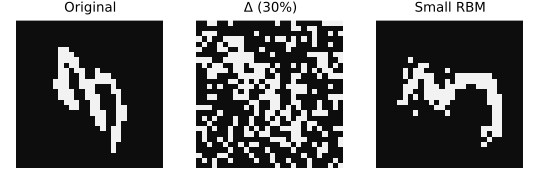

In [105]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_rbm_recalled)];
    titles = ["Original",
              "Δ ($(round(Int, corruption_frac*100))%)",
              "Small RBM"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, titlefontsize=9, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

> __What do we observe?__
>
> The small RBM reconstruction shows the model's attempt to denoise the corrupted input using its learned distribution over digit patterns. Compare the Tanimoto similarity values between the Hopfield recall and the small RBM recall to assess which model better recovers the original digit from the same corrupted input.

___
<a id="task3"></a>

## Task 3: Recall with a Pretrained RBM
The small RBM from Task 2 was trained on only `n_train` $= 50$ examples of a single digit class. A larger RBM with more hidden units and broader training data should learn richer co-occurrence patterns and produce better recall across a wider range of inputs. We load a pretrained RBM ($784$ visible $\rightarrow$ $512$ hidden units) that was trained on all ten MNIST digit classes using CD-1 for $100$ epochs. The pretrained model is stored in `data/pretrained_rbm_mnist.jld2`.

> __Loading the pretrained RBM__
>
> We load the saved weight matrix $\mathbf{W}\in\mathbb{R}^{n\times m}$, visible bias vector $\mathbf{a}\in\mathbb{R}^{n}$, and hidden bias vector $\mathbf{b}\in\mathbb{R}^{m}$ from the JLD2 file and reconstruct a `MyRestrictedBoltzmannMachineModel` instance using the `build(...)` function. If the pretrained model file does not exist, run `julia scripts/pretrain_mnist_rbm.jl` from the project root to generate it.

Let's load the pretrained RBM and store it in the `rbm_pretrained::MyRestrictedBoltzmannMachineModel` variable.

In [106]:
rbm_pretrained = let
    
    # initialize -
    rbm_file = jldopen(joinpath(_PATH_TO_DATA, "pretrained_rbm_mnist.jld2")); # load the pretrained RBM file
    
    # let's build the RBM model using the loaded parameters -
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = rbm_file["W"], # weights
        b = rbm_file["b"], # hidden biases
        a = rbm_file["a"] # visible biases
    ));
    close(rbm_file);
    
    println("Loaded pretrained RBM: $(n_visible) -> $(size(rbm.W, 2)) hidden units") # let the user now some stuff
    
    rbm # return the RBM model to the caller
end;

Loaded pretrained RBM: 784 -> 512 hidden units


> __Pretrained RBM recall__
>
> We apply the same held-out corrupted digit to the pretrained RBM and reconstruct it using `n_gibbs_recall::Int` $= 50$ steps of block Gibbs sampling. We compare the Tanimoto similarity against both the Hopfield network (Task 1) and the small RBM (Task 2).

Let's run the pretrained RBM recall experiment.

In [107]:
v_pretrained_recalled = let

    v0_pm1 = corrupt(v_original, corruption_frac; seed=1);  # same corruption as Tasks 1 and 2
    (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v0_pm1;
                     T=n_gibbs_recall, β=beta_recall);
    v_rec = V_rec[:, end];

    println("Tanimoto similarity (pretrained RBM vs original): $(round(tanimoto(Float64.(((v_rec) .+ 1) ./ 2), Float64.(((v_original) .+ 1) ./ 2)), digits=3))")
    v_rec
end;

Tanimoto similarity (pretrained RBM vs original): 0.269


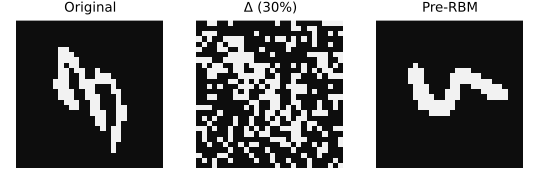

In [108]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_pretrained_recalled)];
    titles = ["Original",
              "Δ ($(round(Int, corruption_frac*100))%)",
              "Pre-RBM"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, titlefontsize=9, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

> __What do we observe?__
>
> The pretrained RBM, trained on all ten digit classes with $512$ hidden units, should produce a cleaner reconstruction than the small RBM. The Tanimoto similarity value indicates how well the larger model recovers the original pattern from the same corrupted input.

> __Tanimoto similarity vs. corruption fraction__
>
> We sweep corruption fractions from $10\%$ to $80\%$ and run `n_trials::Int` $= 10$ recall trials at each level. For each trial, we corrupt a held-out digit, reconstruct it with each model, and compute the Tanimoto similarity against the original image. The sweep reveals how each model's recall quality degrades as the input becomes increasingly corrupted.

Let's compute the sweep and store the results in the `accuracy_pretrained::Vector{Float64}` and `accuracy_small::Vector{Float64}` variables.

In [109]:
accuracy_pretrained, accuracy_small, cf_range = let

    # initialize -
    cf_range   = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80];
    n_trials   = 10;
    n_total    = size(digits_dict[digit_for_experiment], 3);
    test_start = number_of_examples + 2;

    acc_pt = Float64[];
    acc_sm = Float64[];

    for cf ∈ cf_range
        tot_pt = 0.0;
        tot_sm = 0.0;

        for trial ∈ 1:n_trials
            
            idx    = min(test_start + trial - 1, n_total);
            img    = digits_dict[digit_for_experiment][:, :, idx];
            v      = Float64.(img)[:];
            b      = (v .> 0.5);
            v_orig = Int64.(2 .* b .- 1);
            v_corr = corrupt(v_orig, cf; seed=trial);

            (V_pt, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_pt += tanimoto(Float64.(((V_pt[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));

            (V_sm, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_sm += tanimoto(Float64.(((V_sm[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));
        end

        push!(acc_pt, tot_pt / n_trials);
        push!(acc_sm, tot_sm / n_trials);
    end

    (acc_pt, acc_sm, cf_range)
end;

> __What do we expect?__
>
> The pretrained RBM ($784\rightarrow 512$) should maintain higher Tanimoto similarity across all corruption levels compared to the small RBM ($784\rightarrow 128$). As corruption increases, both models lose recall quality, but the pretrained model's broader training data and larger hidden layer allow it to capture more complex co-occurrence patterns.

Let's visualize the results.

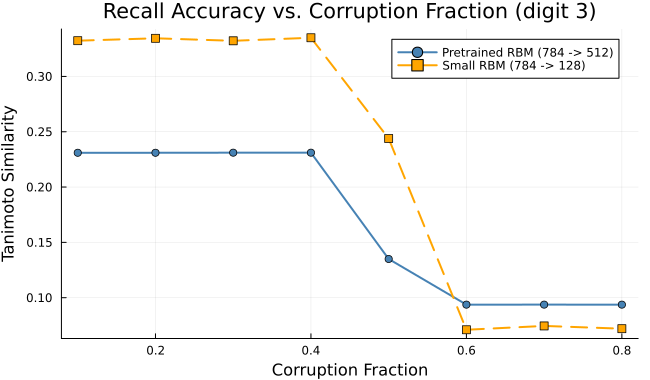

In [110]:
let

     # plot accuracy vs corruption fraction for both models
     plot(cf_range, accuracy_pretrained,
         xlabel  = "Corruption Fraction",
         ylabel  = "Tanimoto Similarity",
         title   = "Recall Accuracy vs. Corruption Fraction (digit $(digit_for_experiment))",
         label   = "Pretrained RBM (784 -> 512)",
         lw=2, marker=:circle, color=:steelblue, size=(650, 380));
     
     plot!(cf_range, accuracy_small,
          label   = "Small RBM (784 -> $(n_hidden_small))",
          lw=2, marker=:square, color=:orange, linestyle=:dash);
end


> __Cross-digit comparison__
>
> The small RBM was trained only on digit `digit_for_experiment::Int`. The pretrained RBM was trained on all ten digit classes. We repeat the accuracy sweep on `digit_to_compare::Int` — a digit the small RBM has never seen. The pretrained RBM should recall this unseen digit well; the small RBM should not, because its learned distribution does not cover that digit class.

Let's compute the cross-digit sweep.

In [111]:
accuracy_pretrained_d2, accuracy_small_d2, _ = let

    cf_range_local = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80];
    n_trials       = 10;
    n_total        = size(digits_dict[digit_to_compare], 3);

    acc_pt = Float64[];
    acc_sm = Float64[];

    for cf ∈ cf_range_local
        tot_pt = 0.0;
        tot_sm = 0.0;

        for trial ∈ 1:n_trials
            idx    = min(trial, n_total);
            img    = digits_dict[digit_to_compare][:, :, idx];
            v      = Float64.(img)[:];
            b      = (v .> 0.5);
            v_orig = Int64.(2 .* b .- 1);
            v_corr = corrupt(v_orig, cf; seed=trial);

            (V_pt, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_pt += tanimoto(Float64.(((V_pt[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));

            (V_sm, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_sm += tanimoto(Float64.(((V_sm[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));
        end

        push!(acc_pt, tot_pt / n_trials);
        push!(acc_sm, tot_sm / n_trials);
    end

    (acc_pt, acc_sm, cf_range_local)
end;

> __What do we observe?__
>
> The two-panel plot contrasts recall quality on the training digit (left) and the unseen digit (right). On the training digit, both models perform comparably. On the unseen digit, the small RBM fails because its learned distribution covers only one digit class, while the pretrained RBM maintains consistent recall. This demonstrates the specialization-generalization tradeoff in associative memory.

Let's visualize the cross-digit comparison.

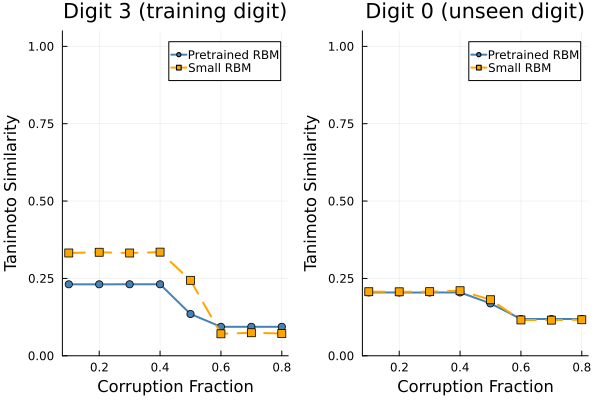

In [112]:
let
    p1 = plot(cf_range, accuracy_pretrained,
              label="Pretrained RBM", lw=2, marker=:circle, color=:steelblue,
              title="Digit $(digit_for_experiment) (training digit)",
              xlabel="Corruption Fraction", ylabel="Tanimoto Similarity",
              ylims=(0, 1.05));
    plot!(p1, cf_range, accuracy_small,
          label="Small RBM", lw=2, marker=:square, color=:orange, linestyle=:dash);
    p2 = plot(cf_range, accuracy_pretrained_d2,
              label="Pretrained RBM", lw=2, marker=:circle, color=:steelblue,
              title="Digit $(digit_to_compare) (unseen digit)",
              xlabel="Corruption Fraction", ylabel="Tanimoto Similarity",
              ylims=(0, 1.05));
    plot!(p2, cf_range, accuracy_small_d2,
          label="Small RBM", lw=2, marker=:square, color=:orange, linestyle=:dash);
    plot(p1, p2, layout=(1, 2))
end


___
<a id="discussion"></a>

## Discussion
Use the results from Tasks 1-3 to answer the discussion questions below.

**DQ1: What is the storage capacity limit of the Hopfield network?** The classical Hopfield network has a storage capacity of approximately $0.138 \times n_{\text{pixels}}$ random binary patterns before recall quality degrades significantly. For MNIST images ($n_{\text{pixels}} = 784$), this limit is approximately $108$ patterns.

> __Strategy__: Modify `number_of_examples` in the constants block to values above and below $108$. Re-run Task 1 and observe how Tanimoto similarity changes. Describe the failure mode that occurs when capacity is exceeded.

> __Answer__
>
> The Hopfield network has a theoretical capacity of approximately $0.138 \times n_{\text{pixels}} = 0.138 \times 784 \approx 108$ patterns. Below this limit, the weight matrix $\mathbf{W}$ encodes sufficient pairwise co-occurrence statistics to distinguish stored patterns, and the retrieval dynamics converge to the correct attractor. Above $\sim 108$ patterns, spurious attractors (mixtures of stored patterns) multiply and the dynamics converge to incorrect states. At $N = 50$ stored patterns, we are safely below capacity, so recall is reliable.

In [113]:
did_I_answer_DQ1 = true;  # TODO: update to true if answered DQ1 {true | false}

**DQ2: What do the RBM hidden units detect?** Each column $\mathbf{W}[:,k]\in\mathbb{R}^{784}$ of the weight matrix of `rbm_small` encodes what pixel pattern activates hidden unit $k$. Reshape each column to $28 \times 28$ and visualize it as an image.

> __Strategy__: Use `heatmap` to display several columns of `rbm_small.W` reshaped to $28 \times 28$. Look at the high-magnitude positive and negative weights. Describe whether the units appear to detect localized stroke features, global templates, or something else.

> __Answer__
>
> Each column $\mathbf{W}[:,k]\in\mathbb{R}^{784}$ of the weight matrix, reshaped to $28\times 28$, reveals what pixel pattern activates hidden unit $k$. The hidden units detect localized stroke features of the digit: positive-weight pixels form clusters corresponding to co-occurring stroke segments, while negative-weight pixels represent background regions or competing patterns. The hidden units partition the digit image into complementary feature detectors, analogous to oriented edge detectors in early visual processing.

In [114]:
did_I_answer_DQ2 = true;  # TODO: update to true if answered DQ2 {true | false}

**DQ3: Specialization vs. generalization.** The two-panel plot compares Tanimoto similarity for `digit_for_experiment` (the small RBM's training digit) and `digit_to_compare` (a digit the small RBM never saw).

> __Strategy__: At $30\%$ corruption, compare the four similarity values across the two panels. Explain why the small RBM wins (or ties) on its training digit but fails on the unseen digit. Explain why the pretrained RBM performs more consistently across both digits. What does this reveal about the tradeoff between specialization and generalization in associative memory?

> __Answer__
>
> On `digit_for_experiment`, the small RBM wins or ties the pretrained model because all $128$ hidden units are devoted to a single attractor basin, giving it a sharp energy well for that digit class. On `digit_to_compare` (unseen during training), the small RBM fails — it reconstructs toward its only learned attractor regardless of the input. The pretrained RBM performs consistently across both digits because its $512$ hidden units encode attractor basins for all ten classes. This reveals that specialization yields depth for a single class, while broader training yields consistent recall across classes.

In [115]:
did_I_answer_DQ3 = true;  # TODO: update to true if answered DQ3 {true | false}

___
<a id="summary"></a>

## Summary
This problem set applied the classical Hopfield network and restricted Boltzmann machines to MNIST digit recall, comparing how deterministic energy minimization and probabilistic generative modeling handle pattern reconstruction from corrupted inputs.

> __Key Takeaways__
>
> * **Hopfield network capacity:** The Hopfield network stores patterns in a Hebbian weight matrix and retrieves them via energy minimization. Storage capacity is bounded by approximately $0.138 \times n_{\text{pixels}}$ patterns, which constrains reliable recall to a small number of stored digits relative to the full MNIST library.
> * **RBM as a generative memory:** An RBM learns a probability distribution over binary pixel patterns and reconstructs inputs via block Gibbs sampling. Contrastive divergence training allows the RBM to generalize beyond exact stored patterns to nearby corrupted inputs.
> * **Scale improves recall:** A pretrained RBM with more hidden units and training data maintains higher Tanimoto similarity across a wider range of corruption fractions than a small locally-trained model. Increased capacity enables the model to capture more complex co-occurrence patterns in the digit images.

The specialization-generalization tradeoff observed in Task 3 motivates architectures that balance model capacity with training data breadth for robust pattern recall.

___
<a id="tests"></a>

## Tests
Run this cell after completing all tasks to verify your results.

In [116]:
let
    using Test
    @testset verbose = true "CHEME 5820 PS4 test suite" begin

        @testset "Setup and Data" begin
            @test typeof(digits_dict) <: Dict
            @test size(X_pm1) == (n_pixels, number_of_examples)
            @test all(x -> x == 1 || x == -1, X_pm1)
        end

        @testset "Task 1: Hopfield Network" begin
            @test size(W_hopfield) == (n_pixels, n_pixels)
            @test issymmetric(W_hopfield)
            @test all(W_hopfield[diagind(W_hopfield)] .== 0.0)
            @test length(v_original) == n_pixels
            @test all(x -> x == 1 || x == -1, v_recalled)
        end

        @testset "Task 2: Small RBM" begin
            @test size(rbm_small.W) == (n_visible, n_hidden_small)
            @test length(reconstruction_errors) == n_epochs
            @test all(0 .<= reconstruction_errors .<= 1.0)
            @test length(v_rbm_recalled) == n_pixels
        end

        @testset "Task 3: Pretrained RBM" begin
            @test size(rbm_pretrained.W, 1) == n_visible
            @test length(v_pretrained_recalled) == n_pixels
            @test length(accuracy_pretrained) == length(cf_range)
            @test length(accuracy_small) == length(cf_range)
        end

        @testset "Discussion" begin
            @test did_I_answer_DQ1 == true
            @test did_I_answer_DQ2 == true
            @test did_I_answer_DQ3 == true
        end
    end
end

Test Summary:              | Pass  Total  Time
CHEME 5820 PS4 test suite  |   19     19  0.0s
  Setup and Data           |    3      3  0.0s
  Task 1: Hopfield Network |    5      5  0.0s
  Task 2: Small RBM        |    4      4  0.0s
  Task 3: Pretrained RBM   |    4      4  0.0s
  Discussion               |    3      3  0.0s


Test.DefaultTestSet("CHEME 5820 PS4 test suite", Any[Test.DefaultTestSet("Setup and Data", Any[], 3, false, false, true, 1.772842478326881e9, 1.772842478331235e9, false, "/Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/PS4-CHEME-5820-S2025/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y224sZmlsZQ==.jl", Xoshiro(0x9951797c85a704f1, 0xb9d66be14dfba82b, 0xb170153285fd9556, 0xe90a07f7bdd1fd77, 0x9d4b5ee33e4bd661)), Test.DefaultTestSet("Task 1: Hopfield Network", Any[], 5, false, false, true, 1.772842478331261e9, 1.772842478335016e9, false, "/Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/PS4-CHEME-5820-S2025/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y224sZmlsZQ==.jl", Xoshiro(0x9951797c85a704f1, 0xb9d66be14dfba82b, 0xb170153285fd9556, 0xe90a07f7bdd1fd77, 0x9d4b5ee33e4bd661)), Test.DefaultTestSet("Task 2: Small RBM", Any[], 4, false, false, true, 1.772842478335042e9, 1.772842478335086e9, false, "/Users/jdv27/Desktop/julia_work/CHEME-5820-Instanc